In [6]:
import torch
print(torch.cuda.is_available())

False


In [2]:
words = open('names.txt', 'r').read().splitlines()

In [3]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [4]:
print(len(words))
print(min(len(w) for w in words))
print(max(len(w) for w in words))

32033
2
15


## Building a Bigram

In [7]:
b = {} # this is a dictionary, we're just counting how much each bigram combination appears 
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1
        # print(ch1, ch2)
        

In [8]:
b

{('<S>', 'e'): 1531,
 ('e', 'm'): 769,
 ('m', 'm'): 168,
 ('m', 'a'): 2590,
 ('a', '<E>'): 6640,
 ('<S>', 'o'): 394,
 ('o', 'l'): 619,
 ('l', 'i'): 2480,
 ('i', 'v'): 269,
 ('v', 'i'): 911,
 ('i', 'a'): 2445,
 ('<S>', 'a'): 4410,
 ('a', 'v'): 834,
 ('v', 'a'): 642,
 ('<S>', 'i'): 591,
 ('i', 's'): 1316,
 ('s', 'a'): 1201,
 ('a', 'b'): 541,
 ('b', 'e'): 655,
 ('e', 'l'): 3248,
 ('l', 'l'): 1345,
 ('l', 'a'): 2623,
 ('<S>', 's'): 2055,
 ('s', 'o'): 531,
 ('o', 'p'): 95,
 ('p', 'h'): 204,
 ('h', 'i'): 729,
 ('<S>', 'c'): 1542,
 ('c', 'h'): 664,
 ('h', 'a'): 2244,
 ('a', 'r'): 3264,
 ('r', 'l'): 413,
 ('l', 'o'): 692,
 ('o', 't'): 118,
 ('t', 't'): 374,
 ('t', 'e'): 716,
 ('e', '<E>'): 3983,
 ('<S>', 'm'): 2538,
 ('m', 'i'): 1256,
 ('a', 'm'): 1634,
 ('m', 'e'): 818,
 ('<S>', 'h'): 874,
 ('r', 'p'): 14,
 ('p', 'e'): 197,
 ('e', 'r'): 1958,
 ('r', '<E>'): 1377,
 ('e', 'v'): 463,
 ('v', 'e'): 568,
 ('l', 'y'): 1588,
 ('y', 'n'): 1826,
 ('n', '<E>'): 6763,
 ('b', 'i'): 217,
 ('i', 'g'): 428,


In [9]:
sorted(b.items(), key = lambda kv: -kv[1]) # sorting by most likely bigrams

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [10]:
import torch

In [32]:
N = torch.zeros((27, 27), dtype=torch.int32)

In [37]:
# len(set(''.join(words)))

# So here we're just creating a look up table
# that will map each character to a specific index
# we need this integer representation so that we can translate
# the characters into a tensor index (i think!)
chars = sorted(list(set(''.join(words))))
print("chars", chars)
stoi = {s:i+1 for i,s in enumerate(chars)}
# stoi['<S>'] = 26
# stoi['<E>'] = 27
stoi['.'] = 0

print(stoi)

chars ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [38]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1
    

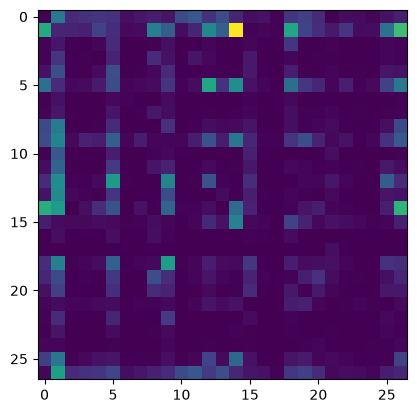

In [39]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(N)

In [40]:
itos = {i:s for s,i  in stoi.items()} # inversing the loopup math
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

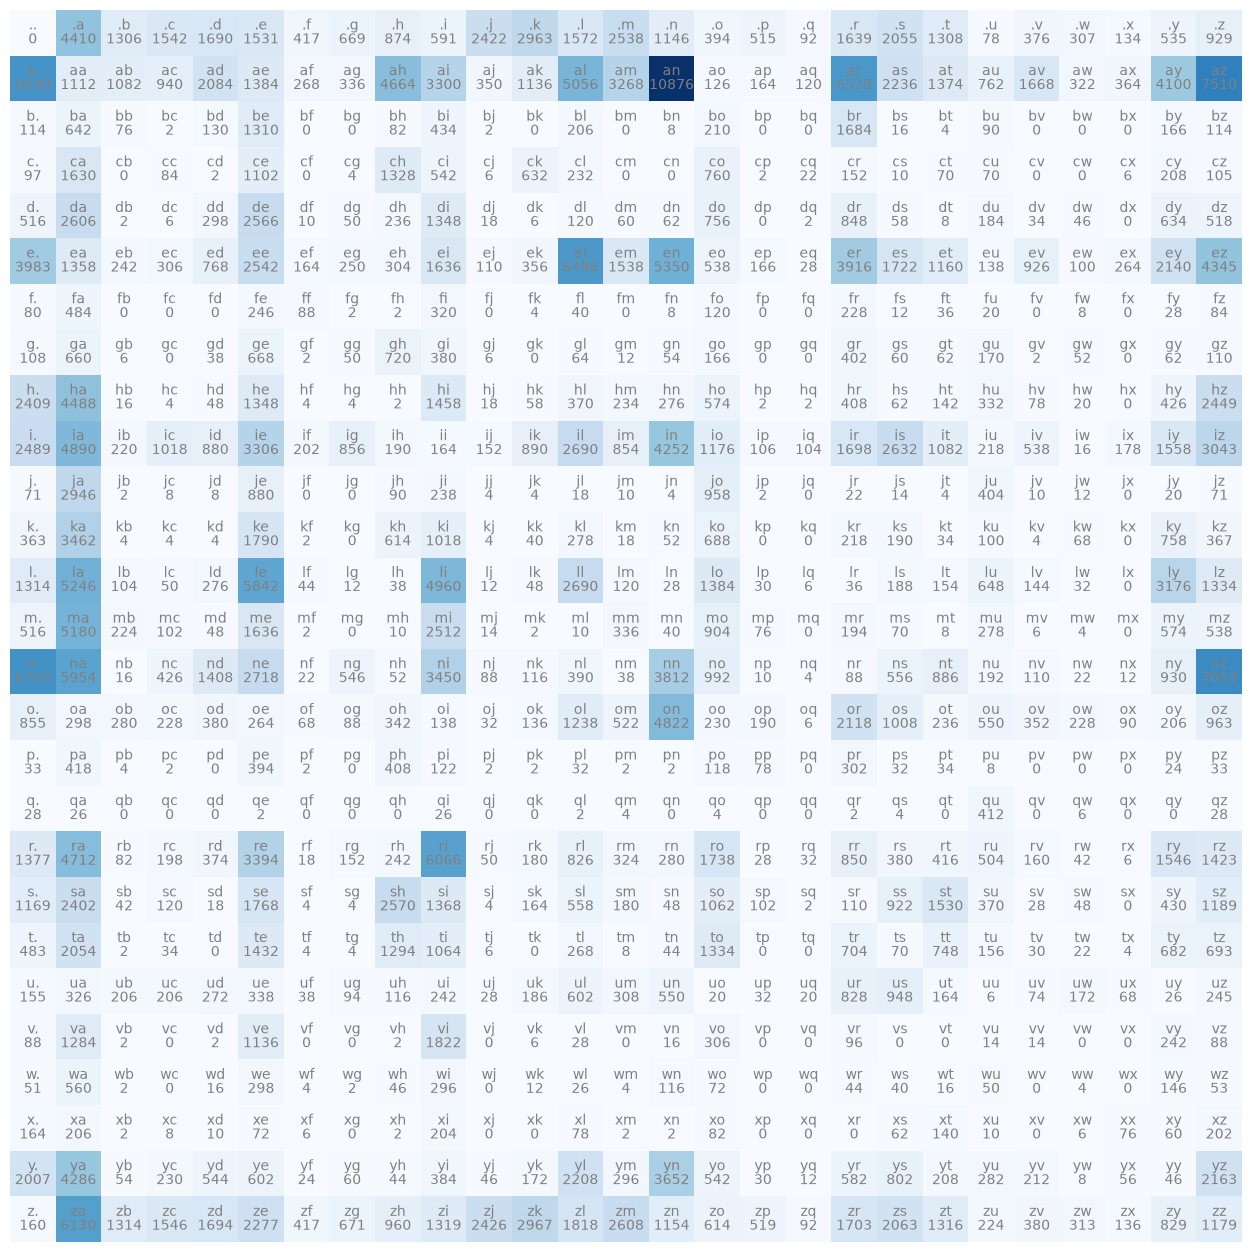

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')

# i typed something wrong around here but i don't really think this is important enough for me to fix
# so i'm just gonna move on for now
# okay so making the changes to remove <S> and <E> fixes it? maybe i just didn't run something in the correct order
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')

plt.axis('off')

In [44]:
N[0, :].shape

torch.Size([27])

In [47]:
# this apparently gives you the probabality of each character being the first character in a word
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [84]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
print("raw (unormalized)", p)

p = p / p.sum()
print("normalized", p)

raw (unormalized) tensor([0.7081, 0.3542, 0.1054])
normalized tensor([0.6064, 0.3033, 0.0903])


In [110]:
torch.multinomial(p, num_samples=100, replacement=True, generator=g)

tensor([0, 0, 1, 0, 0, 1, 1, 0, 1, 2, 0, 0, 2, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0,
        2, 2, 2, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 2,
        2, 0, 1, 0, 0, 1, 0, 0, 2, 0, 0, 0, 1, 0, 1, 0, 2, 1, 0, 0, 0, 0, 0, 2,
        0, 0, 1, 2, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 2, 0, 0, 2, 0, 1,
        0, 1, 0, 0])

In [115]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()

itos[ix]

'.'

In [144]:
g = torch.Generator().manual_seed(2147483647)
for i in range(50):

    output = []
    ix = 0

    while True:
        p = N[ix].float()
        p = p / p.sum()
        
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        
        # print(itos[ix])
        output.append(itos[ix])
        
        if (ix == 0):
            break

    print(''.join(output))
    

cexzmazjallurailezkaynnellzimittain.
llaynzkanza.
stazthubrtthrigotai.
mozjellavo.
ke.
teda.
kalemimmsadey.
nkaviynyzftlspihinivenvorhlasu.
dsordelezgl.
penzaisana.
razdineeezka.
deru.
firit.
gaikajahzabevare.
kiystzelenzanzmenah.
keenzxzalezalmahavazsorozysoshlaitenzmzeegzsiseriyzann.
illeleldolezmeezhalamigamanemin.
asharin.
alcalar.
jayzkazve.
sezazelyzchay.
ranzjazcyviazisashougenil.
beynzarzeallan.
annutetoradzalia.
rddeman.
me.
vifazdaiazazazkyi.
gh.
cryalanzrlaylmazm.
ron.
nahayde.
n.
aienossin.
memph.
cladaieselamedahzynalerzalizjatturironorni.
alkismeamere.
morazm.
veinaronamnnzeliayuleonzeadajeyzkrenariyn.
keika.
soynn.
miudawamurzcansodidezaicandarizzkihazdenoni.
kar.
kavazthzazkesorrlilaanah.
jan.
sshan.
zszcagalaicalazionzavallciny.
bohzen.
caikeladeradefwiea.
festyalolela.
liyzelan.


In [146]:
P = N.float()
P = P / P.sum(1, keepdim=True)

print(P[0].sum())

tensor(1.)
